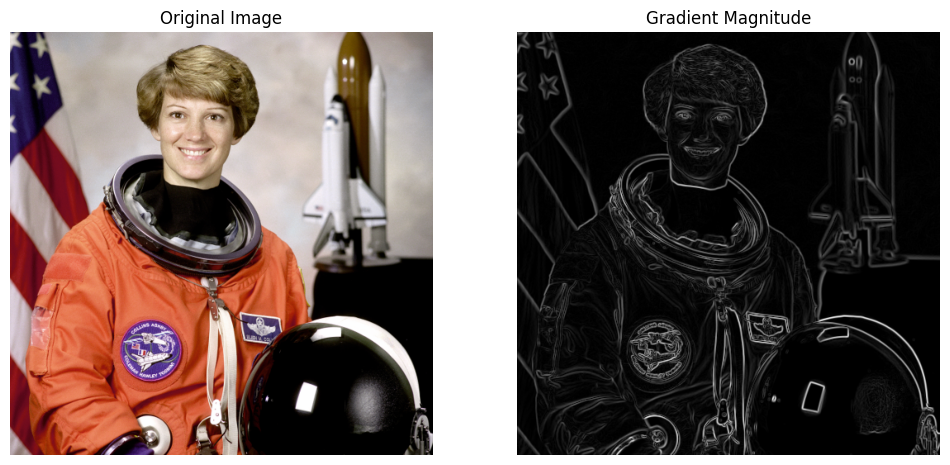

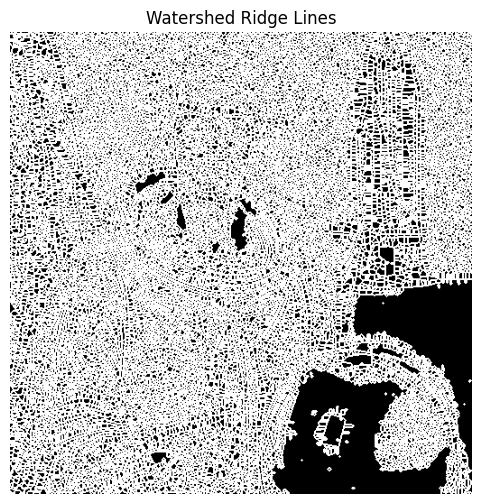

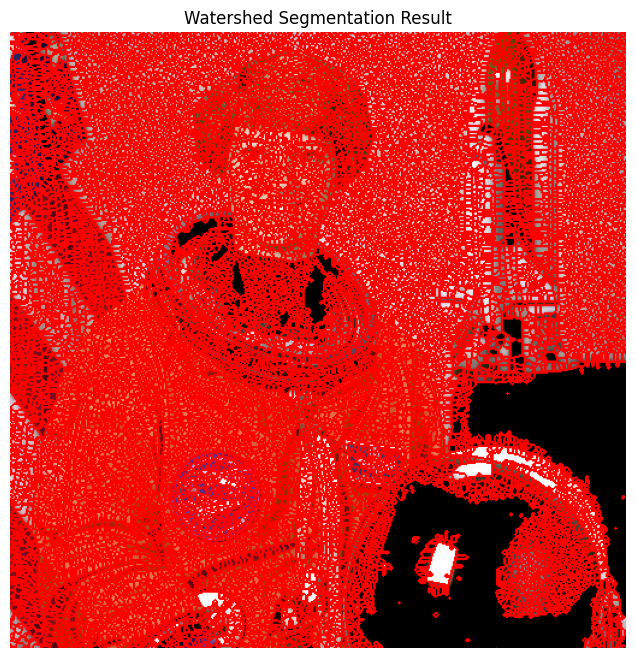

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, filters, segmentation, util

try:
    img = plt.imread('vishal.jpgg')
except FileNotFoundError:
    img = data.astronaut()


#Compute the gradient magnitude

gray = color.rgb2gray(img)

# Compute gradient magnitude (Sobel filter is standard for this)
# This creates the 'topographic map' where edges are high points
gmag = filters.sobel(gray)

# Display Gradient
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gmag, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')
plt.show()

# Apply Watershed transform

labels = segmentation.watershed(gmag)

boundaries = segmentation.find_boundaries(labels)

plt.figure(figsize=(6, 6))
plt.imshow(boundaries, cmap='gray')
plt.title('Watershed Ridge Lines')
plt.axis('off')
plt.show()


# Superimpose boundaries on the original image
img_overlay = img.copy()

if img_overlay.max() <= 1.0:
    img_overlay = (img_overlay * 255).astype(np.uint8)

# Set boundary pixels to Red [255, 0, 0]
img_overlay[boundaries] = [255, 0, 0]

plt.figure(figsize=(8, 8))
plt.imshow(img_overlay)
plt.title('Watershed Segmentation Result')
plt.axis('off')
plt.show()